### Agentic RAG

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS

c:\Users\bhanu\Desktop\AI Agents course\AI-Agents-Learning\AgenticAIWorkspace\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [4]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage,SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_classic import hub as prompts
from langsmith import Client
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import create_retriever_tool
from langchain_core.documents import Document

In [5]:
urls=[
"https://docs.langchain.com/oss/python/langgraph/overview/",
"https://docs.langchain.com/oss/python/langgraph/workflows-agents/",
"https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"
]

In [6]:
docs=[WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview/', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceFault toleranceEvent streamingStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestBackward compatibilityLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontend

In [7]:
doc_list=[doc for sublist in docs for doc in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
doc_splits=text_splitter.split_documents(doc_list)
print(doc_splits[:2])

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview/', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceFault toleranceEvent streamingStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestBackward compatibilityLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendO

In [8]:
vectorstore=FAISS.from_documents(documents=doc_splits,embedding=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2"))

retriever=vectorstore.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2891.87it/s]


In [9]:
retriever.invoke("What is LangGraph?")

[Document(id='cea84b81-af7f-4072-8833-bc24d48c8629', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview/', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='\u200bAcknowledgements\nLangGraph is inspired by Pregel and Apache Beam. The public interface draws inspiration from NetworkX. LangGraph is built by LangChain Inc, the creators of LangChain, but can be used without LangChain.'),
 Document(id='a0e30d9f-5b22-446e-a9ea-9068cf9a7107', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api', 'title': 'Graph API overview - Docs by LangChain', 'language': 'en'}, page_content='At its core, LangGraph models agent workflows as graphs. You define the behavior of your agents using three key components:'),
 Document(id='ae6d88e4-32b1-462f-ace1-4fa6b27ebd06', metadata={'source': 'https://

In [ ]:
# def retriever_tool(state):
#     """Tool to retrieve documents from the Langgraph documentation based on the current question in the state."""
#     query=state["current_question"]
#     docs=retriever.invoke(query)
#     return{"documents":docs}

### Another vector db for langchain blogs

In [10]:
langchain_urls=[
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/rag",
    "https://docs.langchain.com/oss/python/langchain/knowledge-base"
]

langchain_docs=[WebBaseLoader(url).load() for url in langchain_urls]
langchain_docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsA

In [11]:
langchain_doc_list=[doc for sublist in langchain_docs for doc in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
langchain_doc_splits=text_splitter.split_documents(langchain_doc_list)

In [12]:
vectorstore_langchain=FAISS.from_documents(
    documents=langchain_doc_splits,
    embedding=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7459.05it/s]


In [13]:
retriever_langchain=vectorstore_langchain.as_retriever()

In [ ]:
# def langchain_retriever_tool(state):
#     """Tool to retrieve documents from the LangChain documentation based on the current question in the state."""
#     query=state["current_question"]
#     docs=retriever_langchain.invoke(query)
#     return{"documents":docs}

In [ ]:
# tools=[retriever_tool,langchain_retriever_tool]

In [ ]:
def retrieve(state):
    """Tool to retrieve documents from the appropriate database based on the current question in the state. It contains
    two vector dbs, one for LangGraph documentation and another for LangChain documentation. The tool decides which vector db to 
    use based on the question in the state."""
    if state["selected_db"] == "langgraph_vector_db":
        docs = retriever.invoke(state["current_question"])

    else:
        docs = retriever_langchain.invoke(state["current_question"])

    return {
        "documents": docs
    }

### Langgraph workflow

In [15]:
# class AgentState(TypedDict):
#     # The add_messages function defines how an update should be processed
#     # Default is to replace. add_messages says "append"
#     messages:Annotated[Sequence[BaseMessage],add_messages]

class AgentState(TypedDict):
    original_question: str
    current_question: str
    documents: list[Document]
    messages: Annotated[Sequence[BaseMessage], add_messages]
    selected_db:str

In [16]:
llm=ChatGroq(model="openai/gpt-oss-20b")

In [17]:
client = Client()

In [18]:
def init_state(state):
    question = state["messages"][-1].content

    return {
        "original_question": question,
        "current_question": question,
        "documents": ""
    }

In [ ]:
def Agent(state):
    """
    Routes to the appropriate retriever tool based on the question in the state

    Args:
        state(messages): The current state
        
    Returns:
        dict: The updated state with the agent response appended to the router.
    """
    print("---CALL AGENT---")
    # messages=state["current_question"]
    # model=llm.bind_tools(tools)
    # response=model.invoke(messages)

    # return {"messages":[response]}
    # initialize missing fields safely
    class Route(BaseModel):
        retriever: Literal["langchain_vector_db","langgraph_vector_db","END"]
    question = state["current_question"]

    #model = llm.bind_tools(tools)
    response = llm.with_structured_output(Route).invoke([
        SystemMessage(
            content=f"You are an assistant for routing to the respective retriever based on the {question}, if the question is not related to the vector databases, route it to END"
        ),
        HumanMessage(content=question)
    ])

    return {
        "selected_db": response.retriever,
        "messages": [
            AIMessage(content=f"Selected DB: {response.retriever}")
        ]
    }

In [20]:
### Edges
def grade_documents(state)-> Literal["generate","rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.
    
    Args:
        state(messages): The current state
    
    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("--CHECK RELEVANCE---")

    #Data model
    class grade(BaseModel):
        """Binary score for relevacne"""
        binary_score: str=Field(description="Relevance score 'yes' or 'no'")

    llm_with_tool=llm.with_structured_output(grade)

    #Prompt
    prompt=PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevent. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context","question"]
    )

    #Chain
    chain=prompt|llm_with_tool

    # messages=state["messages"]
    # last_message=messages[-1]

    question=state["current_question"]
    docs=state["documents"]

    scored_result=chain.invoke({"question":question,"context":docs})

    score=scored_result.binary_score

    print("DOCUMENTS:", repr(state["documents"]))
    print("LAST MESSAGE TYPE:", type(state["messages"][-1]))
    print("LAST MESSAGE:", state["messages"][-1].content[:200])
    if score =="yes":
        print("--DECISION: DOCS RELEVANT--")
        return "generate"
    else:
        print("--DECISION: DOCS NOT RELEVANT--")
        print(score)
        return "rewrite"

In [21]:
def generate(state):
    """
    Generate answer
    
    Args:
       state(messages); The current state

    Returns:
         dict; The updated message
    """

    print("---GENERATE---")
    messages=state["messages"]
    question=state["current_question"]
    docs = state["documents"]
    formatted_docs = "\n\n".join(
        doc.page_content
        for doc in docs
    )
    #last_message=messages[-1]
    
    # if state["selected_db"] == "langgraph_vector_db":
    #     docs = retriever_tool(state)["documents"]

    # elif state["selected_db"] == "langchain_vector_db":
    #     docs = langchain_retriever_tool(state)["documents"]

    #docs=state["documents"]

    #Prompt
    prompt=client.pull_prompt("rlm/rag-prompt",dangerously_pull_public_prompt=True)

    # def format_docs(docs):
    #     return "\n\n".join(doc.page_content for doc in docs)
    
    #Chain
    rag_chain=prompt | llm | StrOutputParser()

    #Run
    response=rag_chain.invoke({"context":formatted_docs,"question":question})
    return {"messages": [AIMessage(content=response)]}

In [22]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state(messages): The current state

    Returns:
        dict: The updated state with a re-phrased question
    """
    print("---TRANSFORM QUERY---")
    messages=state["messages"]
    question=state["current_question"]

    msg=[
        HumanMessage(
            content=f"""\n
    Look at the input and try to reason about the underlying semantic intent / meaning. \n
    Here is the initial question:
    \n ------\n
    {question}
    \n ------- \n
    Formulate an improved question: """
        )
    ]

    #Grader
    response=llm.invoke(msg)
    return {
        "current_question": response.content,
        "messages": [AIMessage(content=response.content)]
    }

In [23]:
def route_retriever(state):
    return state["selected_db"]

In [24]:
workflow=StateGraph(AgentState)

workflow.add_node("agent",Agent)
workflow.add_node("init_state",init_state)
#retrieve = ToolNode([retriever_tool,langchain_retriever_tool])
workflow.add_node("retrieve", retrieve)
workflow.add_node("rewrite",rewrite)
workflow.add_node("generate",generate)

workflow.add_edge(START,"init_state")
workflow.add_edge("init_state","agent")
workflow.add_conditional_edges(
    "agent",
    route_retriever,
    {
        "langgraph_vector_db": "retrieve",
        "langchain_vector_db": "retrieve",
        END:END
    }
)
workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    {
        "generate": "generate",
        "rewrite": "rewrite"
    }
)
workflow.add_edge("generate",END)
workflow.add_edge("rewrite","agent")

graph=workflow.compile()

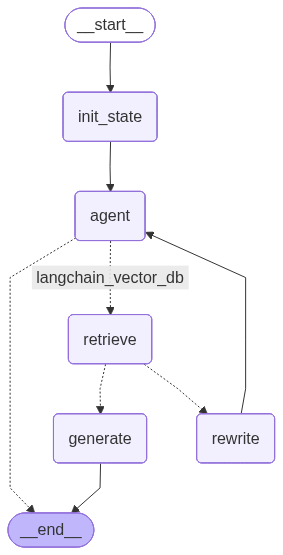

In [ ]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
graph.invoke({"messages":"What is langgraph?"})

---CALL AGENT---
--CHECK RELEVANCE---
DOCUMENTS: [Document(id='cea84b81-af7f-4072-8833-bc24d48c8629', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview/', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='\u200bAcknowledgements\nLangGraph is inspired by Pregel and Apache Beam. The public interface draws inspiration from NetworkX. LangGraph is built by LangChain Inc, the creators of LangChain, but can be used without LangChain.'), Document(id='a0e30d9f-5b22-446e-a9ea-9068cf9a7107', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api', 'title': 'Graph API overview - Docs by LangChain', 'language': 'en'}, page_content='At its core, LangGraph models agent workflows as graphs. You define the behavior of your agents using three key components:'), Document(id='ae6d88e4-32b1-462f-ac

{'original_question': 'What is langgraph?',
 'current_question': 'What is langgraph?',
 'documents': [Document(id='cea84b81-af7f-4072-8833-bc24d48c8629', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview/', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='\u200bAcknowledgements\nLangGraph is inspired by Pregel and Apache Beam. The public interface draws inspiration from NetworkX. LangGraph is built by LangChain Inc, the creators of LangChain, but can be used without LangChain.'),
  Document(id='a0e30d9f-5b22-446e-a9ea-9068cf9a7107', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api', 'title': 'Graph API overview - Docs by LangChain', 'language': 'en'}, page_content='At its core, LangGraph models agent workflows as graphs. You define the behavior of your agents using three

In [27]:
graph.invoke({"messages":"What is langchain?"})

---CALL AGENT---
--CHECK RELEVANCE---
DOCUMENTS: [Document(id='1cf5a2c3-7a2d-4d6e-9a8d-7a03884159f7', metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured output

{'original_question': 'What is langchain?',
 'current_question': 'What is langchain?',
 'documents': [Document(id='1cf5a2c3-7a2d-4d6e-9a8d-7a03884159f7', metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-

In [28]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---
--CHECK RELEVANCE---
DOCUMENTS: [Document(id='f3d564f1-c51c-4d13-a082-c83018a9537c', metadata={'source': 'https://docs.langchain.com/oss/python/langchain/rag', 'title': 'Build a RAG agent with LangChain - Docs by LangChain', 'language': 'en'}, page_content='A RAG agent that executes searches with a simple tool. This is a good general-purpose implementation.\nA two-step RAG chain that uses just a single LLM call per query. This is a fast and effective method for simple queries.\n\n\u200bConcepts\nWe will cover the following concepts:\n\n\nIndexing: a pipeline for ingesting data from a source and indexing it. This usually happens in a separate process.\n\n\nRetrieval and generation: the actual RAG process, which takes the user query at run time and retrieves the relevant data from the index, then passes that to the model.'), Document(id='7bd7d09e-3e34-4311-abb0-5d1ea795a5d8', metadata={'source': 'https://docs.langchain.com/oss/python/langchain/rag', 'title': 'Build a RAG

KeyboardInterrupt: 

The above cell's execution was stopped because it is going into an infinite loop